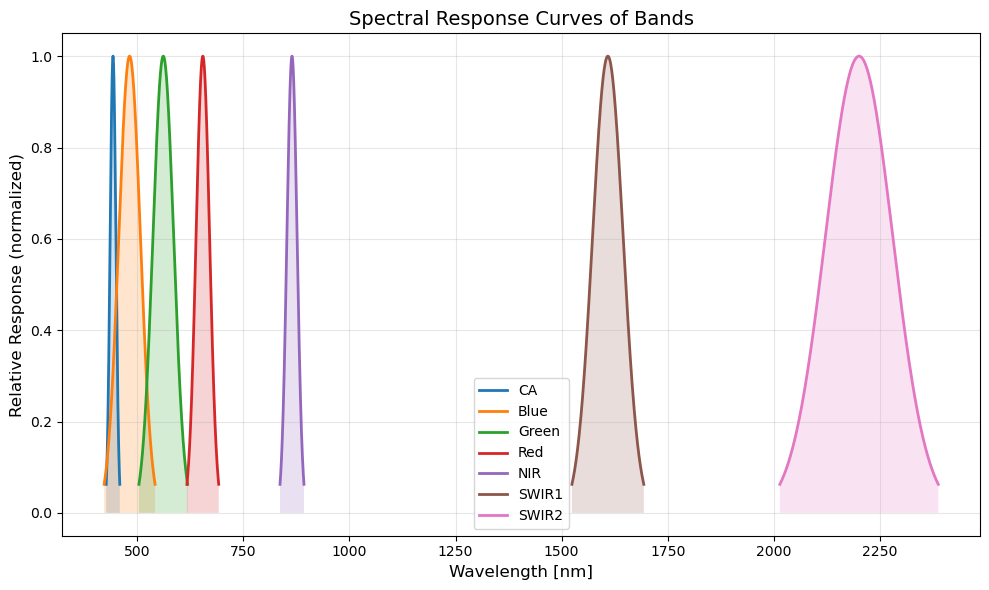

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from astropy.convolution import Gaussian1DKernel, convolve
from joblib import Parallel, delayed
import seaborn as sns
import matplotlib.pyplot as plt


# Band data
Landsat_response = [
    {"name": "CA",     "FWHM": 15.98, "center": 442.96, "lower": 434.97, "upper": 450.95},
    {"name": "Blue",   "FWHM": 60.04, "center": 482.04, "lower": 452.02, "upper": 512.06},
    {"name": "Green",  "FWHM": 57.33, "center": 561.41, "lower": 532.74, "upper": 590.07},
    {"name": "Red",    "FWHM": 37.47, "center": 654.59, "lower": 635.85, "upper": 673.32},
    {"name": "NIR",    "FWHM": 28.25, "center": 864.67, "lower": 850.54, "upper": 878.79},
    {"name": "SWIR1",  "FWHM": 84.72, "center": 1608.86,"lower": 1566.50,"upper": 1651.22},
    {"name": "SWIR2",  "FWHM": 186.66,"center": 2200.73,"lower": 2107.40,"upper": 2294.06},
]


band_names, band_centers, band_fwhm = zip(
    *[(b["name"], b["center"], b["FWHM"]) for b in Landsat_response]
)
band_centers = np.array(band_centers)
band_fwhm = np.array(band_fwhm)

# Create the plot
plt.figure(figsize=(10,6))

# Generate Gaussian curves
for b in Landsat_response:
    wl = np.linspace(b["lower"] - 0.5*b["FWHM"], b["upper"] + 0.5*b["FWHM"], 300)
    response = np.exp(-4*np.log(2)*((wl - b["center"])**2) / (b["FWHM"]**2))
    plt.plot(wl, response, label=b["name"], linewidth=2)
    plt.fill_between(wl, response, alpha=0.2)

# Labeling
plt.xlabel("Wavelength [nm]", fontsize=12)
plt.ylabel("Relative Response (normalized)", fontsize=12)
plt.title("Spectral Response Curves of Bands", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


The plot above was created from parameteres provided from https://landsat.gsfc.nasa.gov/satellites/landsat-8/spacecraft-instruments/operational-land-imager/spectral-response-of-the-operational-land-imager-in-band-band-average-relative-spectral-response/

"The band-average relative spectral radiance responses of the Operational Land Imager (OLI) are provided in this spreadsheet . A summary of the band responses is provided in Table 1. These responses are from measurements made of the fully assembled instrument under thermal vacuum conditions conducted by the instrument vendor, Ball Aerospace & Technologies Corporation (BATC)."

Interestingly this does not correspond with the image provided on their website....

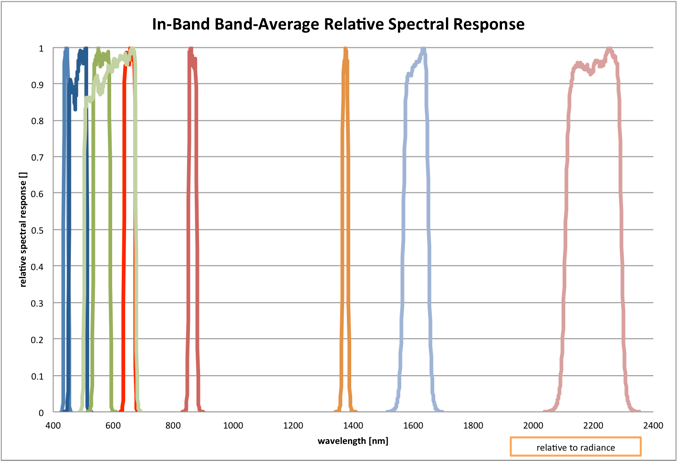

In [2]:


# --- Step 1: Define your resampling function ---
def resample_spectrum(reflectance, wavelengths, band_centers, band_fwhm):
    """
    Resample a spectrum using Gaussian weights.
    
    Parameters:
        reflectance (array): Reflectance values corresponding to 'wavelengths'.
        wavelengths (array): Wavelengths in nanometers.
        band_centers (array): Center wavelengths of target bands.
        band_fwhm (array): Full-width half-max (FWHM) of target bands.

    Returns:
        np.ndarray: Resampled reflectance values per band.
    """
    resampled = np.zeros(len(band_centers))
    for i, (center, fwhm) in enumerate(zip(band_centers, band_fwhm)):
        sigma = fwhm / 2.355  # Convert FWHM to standard deviation
        a = 2 * sigma ** 2
        b = sigma * np.sqrt(2 * np.pi)
        # Create wavelength window ±3σ around the center
        xs = np.arange(int(center - sigma * 3), int(center + sigma * 3) + 1)
        weights = np.exp(-((xs - center) ** 2) / a) / b
        weights = weights / np.max(weights)  # Normalize weights to [0, 1]
        xs_clipped = np.clip(xs, wavelengths[0], wavelengths[-1])
        interp_ref = np.interp(xs_clipped, wavelengths, reflectance)
        resampled[i] = np.sum(interp_ref * weights) / np.sum(weights)
    return resampled




In [ ]:
wavelengths = np.arange(350, 2501)  # adjust as needed
interpolate_lib = True  # whether to interpolate the spectral library to fill missing wavelengths
spectral_lib_path = "99_library_joined.csv" # path to spectral library
#enmap_band_spec_path = "wavelength/enmap_spectral_config.csv"
resampled_out_path = "spectral_library_resampled_landsat_fwmh.csv"

In [4]:

# ------------------------
# Load spectral library
# ------------------------
spectral_lib = pd.read_csv(spectral_lib_path)  # wide format
reflectance_values = spectral_lib[wavelengths.astype(str)].values
# Count rows with at least one NaN
na_count = np.isnan(reflectance_values).any(axis=1).sum()

print(f"Number of rows with NaN in any wavelength column: {na_count}")

Number of rows with NaN in any wavelength column: 1696


C:\Users\schnesha\AppData\Local\Temp\3\ipykernel_38356\962665581.py:4: DtypeWarning: Columns (3,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  spectral_lib = pd.read_csv(spectral_lib_path)  # wide format


In [5]:


# ------------------------
# Resample all reflectance in parallel
# ------------------------
# Initialize array for resampled spectra
reflectance_resampled = np.zeros((reflectance_values.shape[0], len(band_centers)))

reflectance_resampled = np.array(
    Parallel(n_jobs=20)(
        delayed(resample_spectrum)(reflectance_values[i], wavelengths, band_centers, band_fwhm)
        for i in range(reflectance_resampled.shape[0])
    )
)

# Attach metadata and resampled spectra
meta_cols = spectral_lib.drop(columns=wavelengths.astype(str))
reflectance_resampled = pd.concat(
    [
        meta_cols.reset_index(drop=True),
        pd.DataFrame(reflectance_resampled, columns=np.round(band_centers, 2).astype(str))
    ],
    axis=1
)

# count rows with at least one NaN in those columns
wavelength_cols = [c for c in reflectance_resampled.columns if str(c).replace(".", "").isdigit()]
na_count = reflectance_resampled[wavelength_cols].isna().any(axis=1).sum()

print(f"Number of rows with NaN in any wavelength column: {na_count}")

Number of rows with NaN in any wavelength column: 1407


In [6]:
# Count NaNs per wavelength column
na_counts = reflectance_resampled[wavelength_cols].isna().sum()

# Convert wavelength column names to numeric (in case they are strings like '450', '500', etc.)
na_counts.index = na_counts.index.astype(float)

# Sort by wavelength (ascending)
na_counts_sorted = na_counts.sort_index()

na_counts_sorted

442.96     1109
482.04     1109
561.41     1109
654.59     1109
864.67     1314
1608.86    1314
2200.73    1407
dtype: int64

In [7]:

# ------------------------
# Interpolate NaNs in reflectance_values for each sample (row)
# ------------------------
reflectance_values_interpolated = reflectance_values.copy()

for i in range(reflectance_values.shape[0]):
    row = reflectance_values[i]
    nans = np.isnan(row)

    if np.any(nans):
        not_nan_idx = np.where(~nans)[0]
        nan_idx = np.where(nans)[0]

        # only interpolate if there are at least 2 valid points (so we have left & right)
        if len(not_nan_idx) >= 2:
            interpolated = np.interp(nan_idx, not_nan_idx, row[not_nan_idx])
            reflectance_values_interpolated[i, nans] = interpolated
        else:
            # if only one or zero valid points, keep NaNs as NaN
            reflectance_values_interpolated[i, nans] = np.nan
  
# Count rows with at least one NaN
na_count = np.isnan(reflectance_values_interpolated).any(axis=1).sum()

print(f"Number of rows with NaN in any wavelength column: {na_count}")


Number of rows with NaN in any wavelength column: 0


In [8]:
band_centers

array([ 442.96,  482.04,  561.41,  654.59,  864.67, 1608.86, 2200.73])

In [9]:

# ------------------------
# Resample all reflectance in parallel
# ------------------------
# Initialize array for resampled spectra
reflectance_interpolated_resampled = np.zeros((reflectance_values_interpolated.shape[0], len(band_centers)))

reflectance_interpolated_resampled = np.array(
    Parallel(n_jobs=20)(
        delayed(resample_spectrum)(reflectance_values_interpolated[i], wavelengths, band_centers, band_fwhm)
        for i in range(reflectance_interpolated_resampled.shape[0])
    )
)

# Attach metadata and resampled spectra
meta_cols = spectral_lib.drop(columns=wavelengths.astype(str))
reflectance_interpolated_resampled = pd.concat(
    [
        meta_cols.reset_index(drop=True),
        pd.DataFrame(reflectance_interpolated_resampled, columns=np.round(band_centers, 2).astype(str))
    ],
    axis=1
)

# count rows with at least one NaN in those columns
wavelength_cols = [c for c in reflectance_interpolated_resampled.columns if str(c).replace(".", "").isdigit()]
na_count = reflectance_interpolated_resampled[wavelength_cols].isna().any(axis=1).sum()

print(f"Number of rows with NaN in any wavelength column: {na_count}")

Number of rows with NaN in any wavelength column: 0


In [10]:
reflectance_interpolated_resampled

,class,category_1,category_2,property,phenology,life_cycle,state,owner,device,source,id,spectral_range,spectral_sampling,442.96,482.04,561.41,654.59,864.67,1608.86,2200.73
0,GV,shrub,eastwood's manzanita,leaf,evergreen,perennial,CA,ucsb,asd,ecostress_lib_merged_meta_spec_relab_filtered.csv,vegetation.shrub.arctostaphylos.glandulosa.vsw...,350-2500,[1],0.080651,0.093839,0.145858,0.097465,0.462374,0.234953,0.112487
1,GV,tree,sugar pine,needle,evergreen,perennial,CA,ucsb,asd,ecostress_lib_merged_meta_spec_relab_filtered.csv,vegetation.tree.pinus.lambertiana.vswir.vh051....,350-2500,[1],0.050757,0.059019,0.109403,0.068741,0.526010,0.202169,0.094477
2,GV,shrub,california laurel,leaf,evergreen,perennial,CA,ucsb,asd,ecostress_lib_merged_meta_spec_relab_filtered.csv,vegetation.shrub.umbellularia.californica.vswi...,350-2500,[1],0.084567,0.094506,0.150298,0.096729,0.634434,0.374821,0.183935
3,GV,tree,white fir,needle,evergreen,perennial,CA,ucsb,asd,ecostress_lib_merged_meta_spec_relab_filtered.csv,vegetation.tree.abies.concolor.vswir.vh245.ucs...,350-2500,[1],0.099900,0.111434,0.163622,0.112930,0.610959,0.276765,0.142240
4,GV,shrub,foxtail agave,leaf,evergreen,perennial,CA,jpl,asd,ecostress_lib_merged_meta_spec_relab_filtered.csv,vegetation.shrub.agave.attenuata.vswir.jpl063....,350-2500,[1],0.083089,0.102249,0.204865,0.111151,0.685295,0.143781,0.079460
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2626,NPV,NaN,tan oak bark #3,bark,NaN,NaN,CA,Matt Clark,ASD,matt_asd_spectral_library_tidy.csv,Matt_lib_108,352-2350,[1],0.020338,0.026914,0.052498,0.057691,0.273009,0.380121,0.246240
2627,NPV,NaN,tan oak litter,senesced leaves,NaN,NaN,CA,Matt Clark,ASD,matt_asd_spectral_library_tidy.csv,Matt_lib_109,352-2350,[1],0.077619,0.093210,0.131417,0.189557,0.323060,0.438500,0.301827
2628,CHAR,char,unburned manzanita,bark,evergreen,perennial,CA,Matt Clark,ASD,matt_asd_spectral_library_tidy.csv,Matt_lib_110,352-2350,[1],0.021568,0.024319,0.035526,0.079243,0.290580,0.180718,0.093530
2629,GV,tree,valley oak - yellow/green,leaf,deciduous,perennial,CA,Matt Clark,ASD,matt_asd_spectral_library_tidy.csv,Matt_lib_111,352-2350,[1],0.034454,0.042783,0.100636,0.088945,0.315020,0.210338,0.116742


In [11]:

# ------------------------
# Save resampled reflectance_values
# ------------------------
reflectance_resampled.to_csv(resampled_out_path, index=False)

if interpolate_lib:  # whether to interpolate the spectral library to fill missing wavelengths
    reflectance_interpolated_resampled.to_csv(resampled_out_path, index=False)
    reflectance_resampled = reflectance_interpolated_resampled




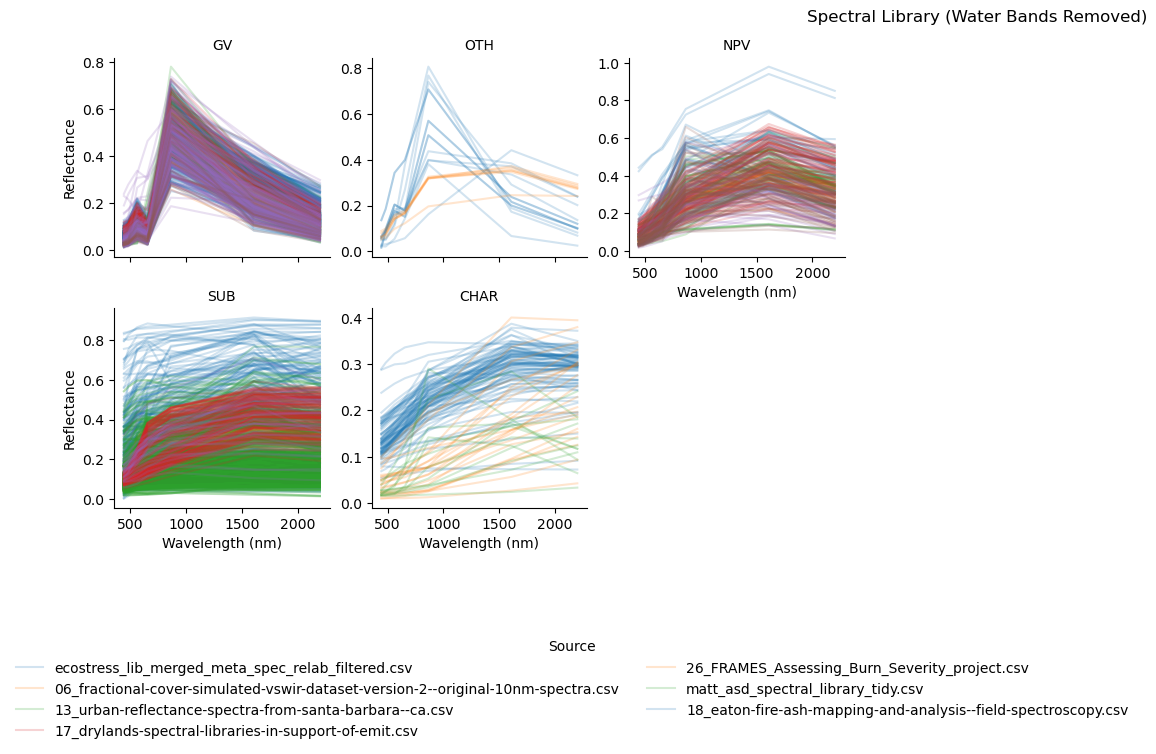

In [12]:

# --- reshape like pivot_longer ---
meta_cols = ["class", "category_1",	"category_2", "id", "source"]  # include source

wavelength_cols = [c for c in reflectance_resampled.columns if str(c).replace(".", "").isdigit()]

df_long = reflectance_resampled.melt(
    id_vars=meta_cols,
    value_vars=wavelength_cols,
    var_name="wavelength",
    value_name="reflectance"
)

df_long["wavelength"] = pd.to_numeric(df_long["wavelength"], errors="coerce")

# --- plotting ---
g = sns.FacetGrid(df_long, col="class", col_wrap=3, sharey=False, sharex=True)
g.map_dataframe(
    sns.lineplot,
    x="wavelength",
    y="reflectance",
    hue="source",      # color by source
    units="id",        # separate lines per spectrum
    estimator=None,    # raw lines
    alpha=0.2          # slight transparency
)

g.set_axis_labels("Wavelength (nm)", "Reflectance")
g.set_titles("{col_name}")

# Move legend to the bottom
g.add_legend(title="Source", bbox_to_anchor=(0.3, -0.05), loc="upper center", ncol=2)
plt.subplots_adjust(top=0.9, bottom=0.15)
g.fig.suptitle("Spectral Library (Water Bands Removed)")
plt.show()


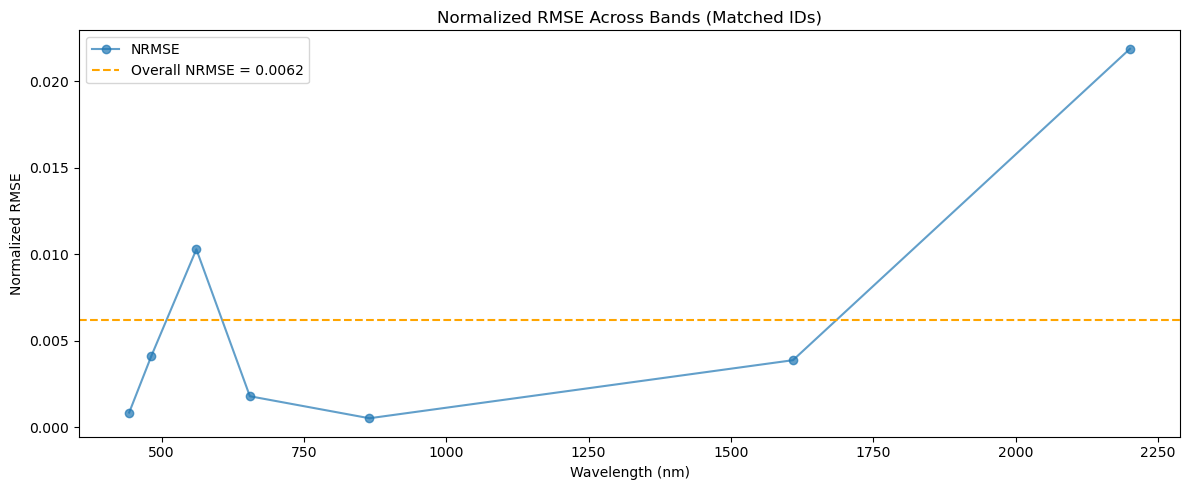

In [13]:
# Find numeric wavelength columns in spectral_lib
spectral_lib_wavelength_cols = [c for c in spectral_lib.columns if str(c).replace(".", "").replace("-", "").isdigit()]

#Convert to float for matching 
reflectance_resampled_wls = np.array([float(w) for w in wavelength_cols]) 
spec_lib_wls = np.array([float(w) for w in spectral_lib_wavelength_cols]) 
# For each reflectance_resampled wavelength, find the closest in spectral_lib 
closest_spec_lib_cols = [spectral_lib_wavelength_cols[np.argmin(np.abs(spec_lib_wls - w))] for w in reflectance_resampled_wls]


# Find matching ids 
matching_ids = list(set(reflectance_resampled['id']).intersection(set(spectral_lib['id'])))
# Filter both DataFrames to matching ids 
reflectance_resampled_matched = reflectance_resampled[reflectance_resampled['id'].isin(matching_ids)].set_index('id')
spectral_lib_matched = spectral_lib[spectral_lib['id'].isin(matching_ids)].set_index('id')


# Calculate NRMSE per band
nrmse_per_band = []
for out_col, spec_col in zip(wavelength_cols, closest_spec_lib_cols):
    arr1 = reflectance_resampled_matched.loc[matching_ids, out_col].astype(float).values
    arr2 = spectral_lib_matched.loc[matching_ids, spec_col].astype(float).values
    
    # Compute RMSE
    rmse = np.sqrt(np.nanmean((arr1 - arr2)**2))
    
    # Normalize by range of reference (min-max)
    range_ref = np.nanmax(arr2) - np.nanmin(arr2)
    nrmse = rmse / range_ref if range_ref != 0 else np.nan
    nrmse_per_band.append(nrmse)

# Overall NRMSE across all bands
overall_nrmse = np.nanmean(nrmse_per_band)

# Plot NRMSE per band
plt.figure(figsize=(12, 5))
plt.plot(sorted([float(w) for w in closest_spec_lib_cols]), nrmse_per_band, marker='o', linestyle='-', alpha=0.7, label="NRMSE")
plt.axhline(overall_nrmse, color='orange', linestyle='--', label=f"Overall NRMSE = {overall_nrmse:.4f}")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Normalized RMSE")
plt.ticklabel_format(style='plain', axis='y')
plt.title("Normalized RMSE Across Bands (Matched IDs)")
plt.legend()
plt.tight_layout()
plt.show()


In [14]:
reflectance_resampled

,class,category_1,category_2,property,phenology,life_cycle,state,owner,device,source,id,spectral_range,spectral_sampling,442.96,482.04,561.41,654.59,864.67,1608.86,2200.73
0,GV,shrub,eastwood's manzanita,leaf,evergreen,perennial,CA,ucsb,asd,ecostress_lib_merged_meta_spec_relab_filtered.csv,vegetation.shrub.arctostaphylos.glandulosa.vsw...,350-2500,[1],0.080651,0.093839,0.145858,0.097465,0.462374,0.234953,0.112487
1,GV,tree,sugar pine,needle,evergreen,perennial,CA,ucsb,asd,ecostress_lib_merged_meta_spec_relab_filtered.csv,vegetation.tree.pinus.lambertiana.vswir.vh051....,350-2500,[1],0.050757,0.059019,0.109403,0.068741,0.526010,0.202169,0.094477
2,GV,shrub,california laurel,leaf,evergreen,perennial,CA,ucsb,asd,ecostress_lib_merged_meta_spec_relab_filtered.csv,vegetation.shrub.umbellularia.californica.vswi...,350-2500,[1],0.084567,0.094506,0.150298,0.096729,0.634434,0.374821,0.183935
3,GV,tree,white fir,needle,evergreen,perennial,CA,ucsb,asd,ecostress_lib_merged_meta_spec_relab_filtered.csv,vegetation.tree.abies.concolor.vswir.vh245.ucs...,350-2500,[1],0.099900,0.111434,0.163622,0.112930,0.610959,0.276765,0.142240
4,GV,shrub,foxtail agave,leaf,evergreen,perennial,CA,jpl,asd,ecostress_lib_merged_meta_spec_relab_filtered.csv,vegetation.shrub.agave.attenuata.vswir.jpl063....,350-2500,[1],0.083089,0.102249,0.204865,0.111151,0.685295,0.143781,0.079460
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2626,NPV,NaN,tan oak bark #3,bark,NaN,NaN,CA,Matt Clark,ASD,matt_asd_spectral_library_tidy.csv,Matt_lib_108,352-2350,[1],0.020338,0.026914,0.052498,0.057691,0.273009,0.380121,0.246240
2627,NPV,NaN,tan oak litter,senesced leaves,NaN,NaN,CA,Matt Clark,ASD,matt_asd_spectral_library_tidy.csv,Matt_lib_109,352-2350,[1],0.077619,0.093210,0.131417,0.189557,0.323060,0.438500,0.301827
2628,CHAR,char,unburned manzanita,bark,evergreen,perennial,CA,Matt Clark,ASD,matt_asd_spectral_library_tidy.csv,Matt_lib_110,352-2350,[1],0.021568,0.024319,0.035526,0.079243,0.290580,0.180718,0.093530
2629,GV,tree,valley oak - yellow/green,leaf,deciduous,perennial,CA,Matt Clark,ASD,matt_asd_spectral_library_tidy.csv,Matt_lib_111,352-2350,[1],0.034454,0.042783,0.100636,0.088945,0.315020,0.210338,0.116742


In [15]:
wavelength_cols

['442.96', '482.04', '561.41', '654.59', '864.67', '1608.86', '2200.73']

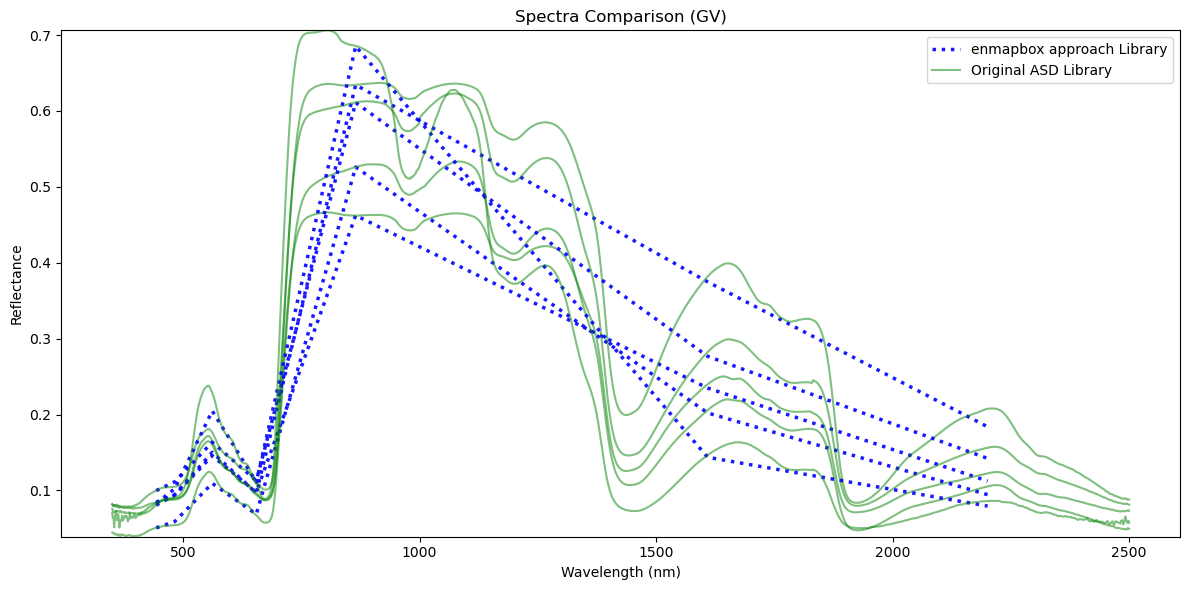

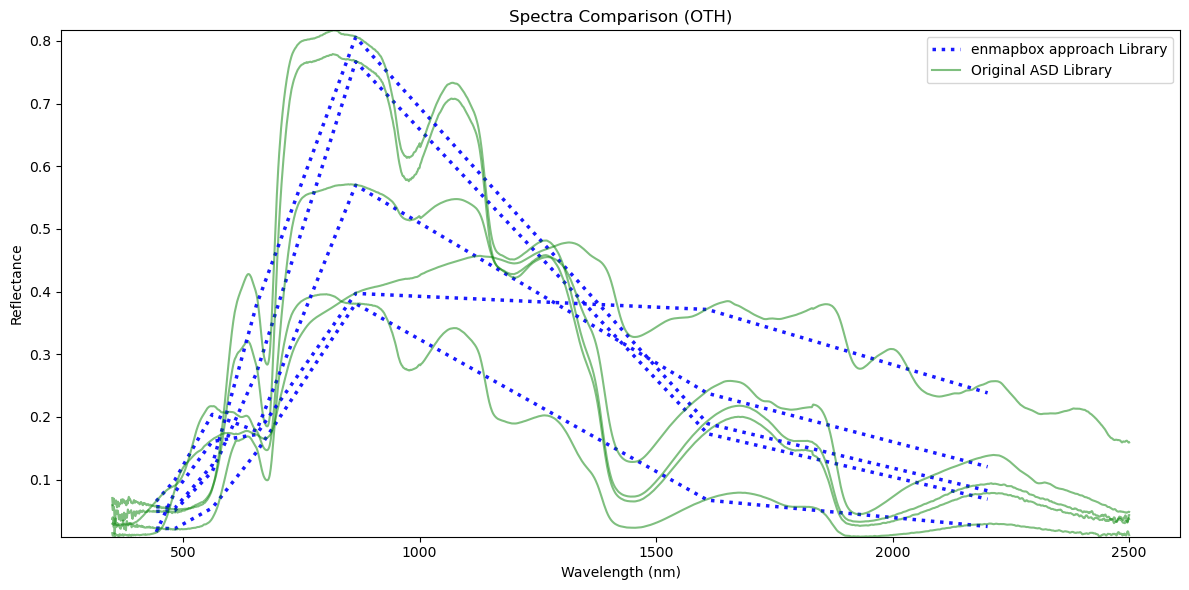

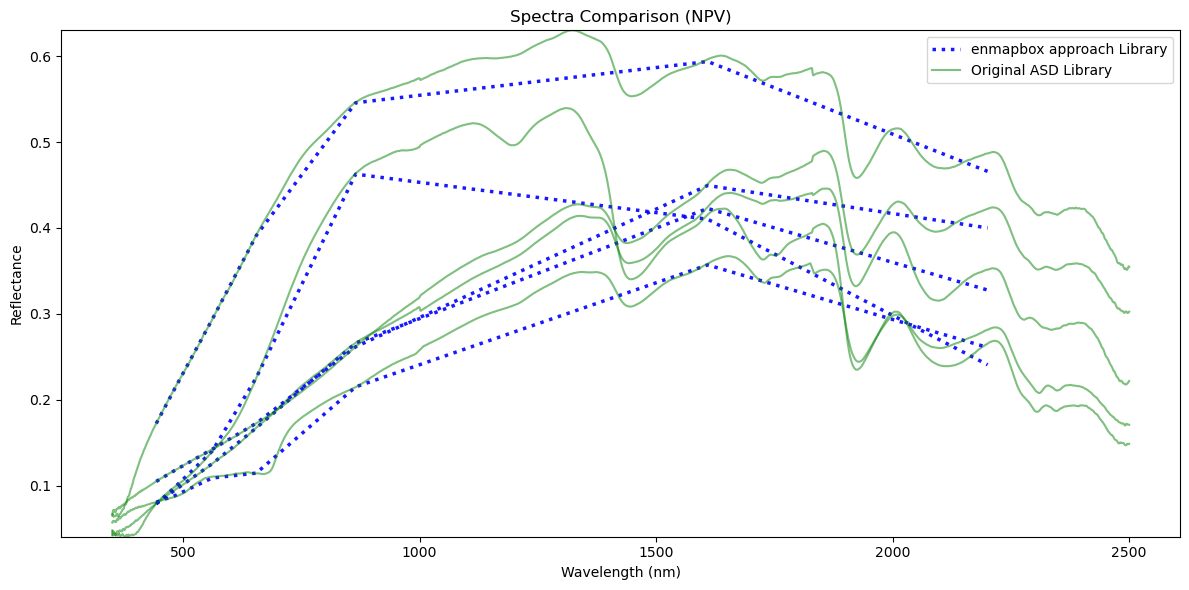

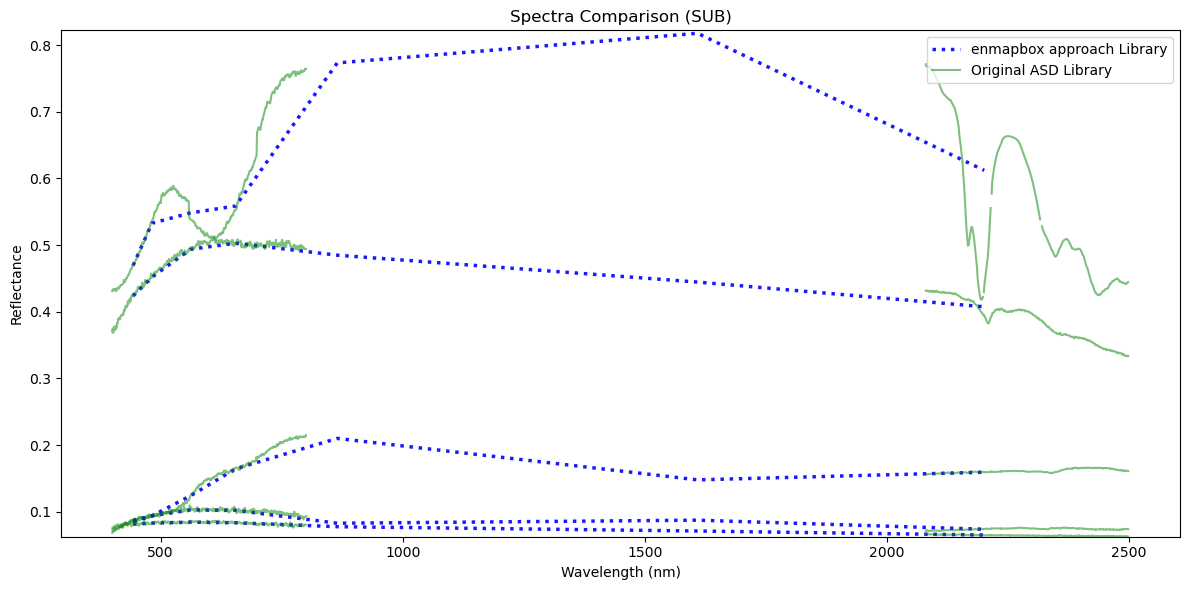

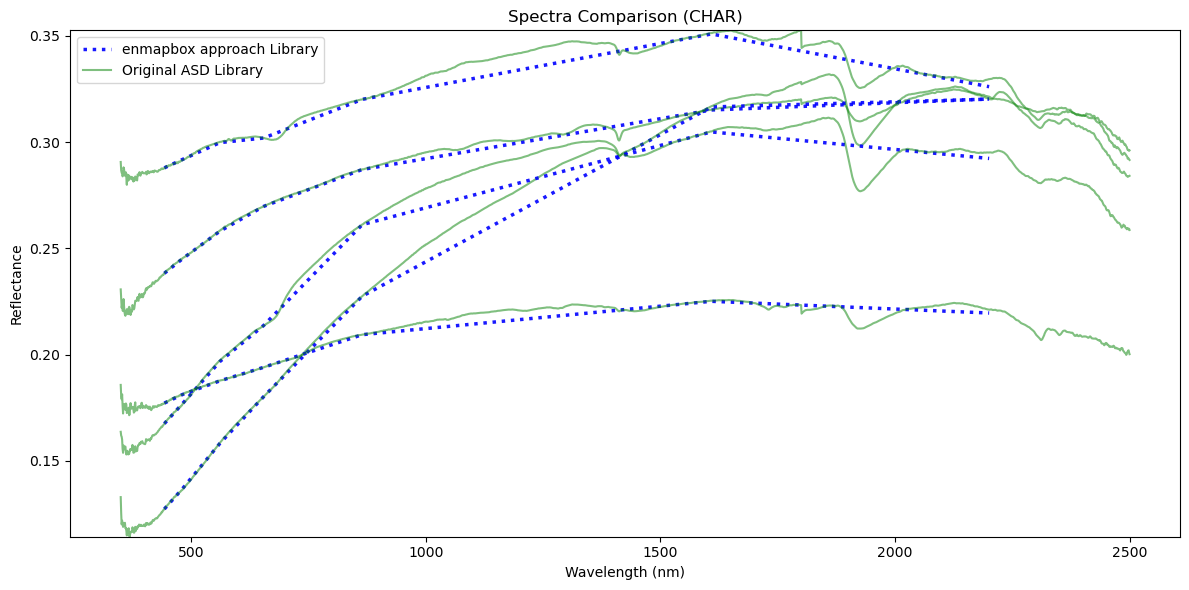

In [16]:
# Define band centers as floats
wavelength_cols = [float(x) for x in wavelength_cols]

# Loop through each class and plot spectra
classes = reflectance_resampled['class'].unique()

for cls in classes:
    # Pick up to 5 spectra per class that exist in matching_ids
    cls_ids = reflectance_resampled.loc[reflectance_resampled['class'] == cls, 'id']
    cls_matching_ids = [i for i in cls_ids if i in matching_ids][:5]
    
    if not cls_matching_ids:
        continue

    plt.figure(figsize=(12, 6))
    all_vals = []

    for sid in cls_matching_ids:
        # Get reflectance (EnMAP resampled)
        spec1 = (
            reflectance_resampled.set_index('id')
            .loc[sid, [str(w) for w in wavelength_cols]]  # convert column names to str
            .astype(float)
            .values
        )

        plt.plot(wavelength_cols, spec1, alpha=0.9, linestyle=':', color="blue", linewidth=2.5)

        # Get ASD library spectrum
        spec3 = (
            spectral_lib.set_index('id')
            .loc[sid, [str(int(w)) for w in wavelengths]]
            .astype(float)
            .values
        )

        plt.plot(wavelengths, spec3, alpha=0.5, linestyle='-', color='green', linewidth=1.5)
        
        all_vals.extend(spec1)
        all_vals.extend(spec3)

    plt.legend(["enmapbox approach Library", "Original ASD Library"])
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Reflectance")
    plt.title(f"Spectra Comparison ({cls})")
    plt.ylim(np.nanmin(all_vals), np.nanmax(all_vals))
    plt.tight_layout()
    plt.show()

